In [57]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pystac_client
import xarray as xr
from pystac_client import CollectionSearch
from matplotlib.gridspec import GridSpec
import rioxarray as rxr

In [97]:
 bbox = [-65.78-1,  -62.69-1, -65.78,  -62.69]

In [98]:
collection_dict

{'id': 'sentinel-3-slstr-l2-lst',
 'type': 'Collection',
 'links': [{'rel': 'items',
   'type': 'application/geo+json',
   'href': 'https://stac.core.eopf.eodc.eu/collections/sentinel-3-slstr-l2-lst/items'},
  {'rel': 'parent',
   'type': 'application/json',
   'href': 'https://stac.core.eopf.eodc.eu/'},
  {'rel': 'root',
   'type': 'application/json',
   'href': 'https://stac.core.eopf.eodc.eu/'},
  {'rel': 'self',
   'type': 'application/json',
   'href': 'https://stac.core.eopf.eodc.eu/collections/sentinel-3-slstr-l2-lst'},
  {'rel': 'license',
   'href': 'https://sentinel.esa.int/documents/247904/690755/Sentinel_Data_Legal_Notice',
   'type': 'application/pdf',
   'title': 'Legal notice on the use of Copernicus Sentinel Data and Service Information'},
  {'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
   'type': 'application/schema+json',
   'title': 'Queryables',
   'href': 'https://stac.core.eopf.eodc.eu/collections/sentinel-3-slstr-l2-lst/queryables'}],
 'title': 'Se

In [99]:
# Initialize the collection search
search = CollectionSearch(
    url="https://stac.core.eopf.eodc.eu/collections",  # STAC /collections endpoint
)

# Retrieve all matching collections (as dictionaries)
for collection_dict in search.collections_as_dicts():
    print(collection_dict["id"])

sentinel-2-l2a
sentinel-1-l2-ocn
sentinel-3-slstr-l1-rbt
sentinel-3-olci-l2-lrr
sentinel-3-olci-l2-lfr
sentinel-2-l1c
sentinel-3-olci-l1-efr
sentinel-1-l1-grd
sentinel-3-slstr-l2-frp
sentinel-1-l1-slc
sentinel-3-olci-l1-err
sentinel-3-slstr-l2-lst


In [101]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
# Search with cloud cover filter
items = list(
    catalog.search(
        collections=["sentinel-3-olci-l2-lfr"],
        bbox=bbox,#[7.2, 44.5, 7.4, 44.7],
        #datetime=["2020-02-01", "2025-02-15"],
        #query={"eo:cloud_cover": {"lt": 20}},  # Cloud cover less than 20%
    ).items()
)
print(len(items))

69


In [ ]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
# Search with cloud cover filter
items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,#[7.2, 44.5, 7.4, 44.7],
        datetime=["2020-02-01", "2025-02-15"],
        #query={"eo:cloud_cover": {"lt": 20}},  # Cloud cover less than 20%
    ).items()
)
print(items)

[<Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T16DDJ_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T15DXD_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T15DXC_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T15DWE_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T15DWD_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T15DWC_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T15DVE_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T15DVD_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T14DPK_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T14DPJ_20241201T184346>, <Item id=S2A_MSIL2A_20241201T151221_N0511_R139_T14DNK_20241201T184346>]


In [92]:
len(items)

11

In [ ]:
items[0]

In [77]:
 item.assets["product"].extra_fields["xarray:open_datatree_kwargs"]

{'chunks': {}, 'engine': 'eopf-zarr', 'op_mode': 'native'}

In [102]:
item = items[4]
ds_default = xr.open_dataset(item.assets["product"].href, engine="eopf-zarr", chunks={}, op_mode='analysis')

In [94]:
ds_default

<xarray.Dataset> Size: 12GB
Dimensions:      (x: 10980, y: 10980)
Coordinates:
  * x            (x) int64 88kB 499985 499995 500005 ... 609755 609765 609775
  * y            (y) int64 88kB 2400035 2400025 2400015 ... 2290255 2290245
    spatial_ref  int64 8B ...
    band         int64 8B ...
Data variables: (12/15)
    b02          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b04          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b08          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b01          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b05          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    ...           ...
    b12          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    cld          (y, x) uint8 121MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    snw          (y, x) uint8 121MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    scl          (y, x) uint8 121MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (34)

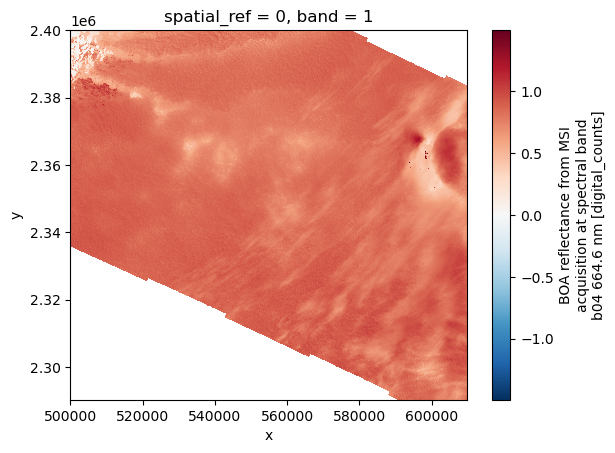

In [96]:
ds_default.b04.plot.imshow()

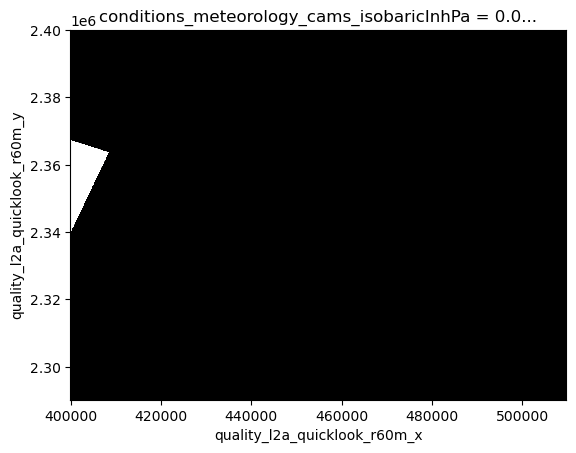

In [81]:
ds.quality_l2a_quicklook_r60m_tci.plot.imshow(rgb="quality_l2a_quicklook_r60m_band")

In [40]:
len(items)

5

In [42]:
item

<Item id=S2B_MSIL2A_20200207T134959_R081_T20ELR_20201001T071916>

In [60]:
items[0].assets['B01'].href

'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/20/E/LR/2020/02/07/S2B_MSIL2A_20200207T134959_N0212_R081_T20ELR_20201001T071916.SAFE/GRANULE/L2A_T20ELR_A015265_20200207T134958/IMG_DATA/R60m/T20ELR_20200207T134959_B01_60m.tif'

In [61]:
ds = rxr.open_rasterio(items[0].assets['B01'].href,)# 

RasterioIOError: HTTP response code: 409

In [56]:
ds_default = xr.open_dataset(items[0].assets['preview'].href,)# engine="eopf-zarr", chunks={})

syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: ﻿<?xml^ version="1.0" encoding="utf-8"?><Error><Code>PublicAccessNotPermitted</Code><Message>Public access is not permitted on this storage account.RequestId:bcff3f3b-b01e-005b-553f-69d395000000Time:2025-12-09T19:09:35.1319339Z</Message></Error>


OSError: [Errno -77] NetCDF: Access failure: 'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/20/E/LR/2020/02/07/S2B_MSIL2A_20200207T134959_N0212_R081_T20ELR_20201001T071916.SAFE/GRANULE/L2A_T20ELR_A015265_20200207T134958/QI_DATA/T20ELR_20200207T134959_PVI.tif'

In [41]:
item = items[0]  # extracting the first item

ds_default = xr.open_dataset(item.assets["product"].href, engine="eopf-zarr", chunks={})

KeyError: 'product'

In [ ]:
https://objectstore.eodc.eu:2222/e05ab01a9d56408d82ac32d69a5aae2a:202505-s02msil2a/18/products/cpm_v256/S2B_MSIL2A_20250518T112119_N0511_R037_T29RLL_20250518T140519.zarr/measurements/reflectance/r10m

<xarray.Dataset> Size: 12GB
Dimensions:      (x: 10980, y: 10980)
Coordinates:
  * x            (x) int64 88kB 300005 300015 300025 ... 409775 409785 409795
  * y            (y) int64 88kB 5000035 5000025 5000015 ... 4890255 4890245
    spatial_ref  int64 8B ...
    band         int64 8B ...
Data variables: (12/15)
    b02          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b03          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b04          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b08          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b01          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b05          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    ...           ...
    b12          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b8a          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    cld          (y, x) uint8 121MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    snw          (y, x) uint8 121MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    scl          (y, x) uint8 121MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
    b09          (y, x) float64 964MB dask.array<chunksize=(1830, 1830), meta=np.ndarray>
Attributes: (34)

In [ ]:
item = items[0]  # extracting the first item

ds = xr.open_dataset(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],)
  # The engine="eopf-zarr" is already embedded in the STAC metadata

# `ds.quality_l2a_quicklook_r60m_tci.plot.imshow(rgb="quality_l2a_quicklook_r60m_band")`

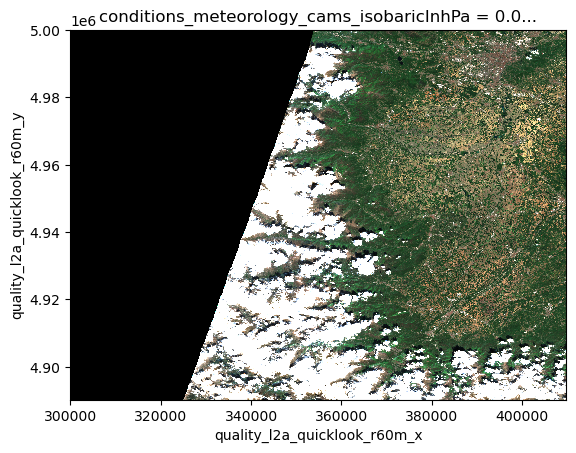

In [18]:
ds.quality_l2a_quicklook_r60m_tci.plot.imshow(rgb="quality_l2a_quicklook_r60m_band")